Load Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy import stats
import seaborn as sns



Load Dataset, cleanup

In [46]:

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv('data.csv', sep='\t')
    names = pd.read_excel('variable_names.xlsx')
    print("Dataset has been successfully loaded.")
except Exception as e:
    print(f"Failed to load data: {e}")

C:\Users\alexh\AppData\Local\Temp\ipykernel_31484\1803426984.py:3: DtypeWarning: Columns (0,2,4,5,6,8,9,10,12,13,14,16,17,18,20,21,22,24,25,26,28,29,30,32,33,34,36,37,38,40,41,42,44,45,46,48,49,50,52,53,54,56,57,58,60,61,62,64,65,66,68,69,70,72,73,74,76,77,78,80,81,82,84,85,86,88,89,90,92,93,94,96,97,98,100,101,102,104,105,106,108,109,110,112,113,114,116,117,118,120,121,122,124,125,126,128,129) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', sep='\t')


Dataset has been successfully loaded.


In [47]:
#Begin Real Cleanup
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
date = df['date']
print(df.duplicated().sum())

df.dropna(inplace=True)


names.columns = ['variable', 'type', 'descr']

mappings = names[['variable', 'descr']]

print(df.head())

df.to_csv("cleaned_data.csv", index=False)
mappings.to_csv("mappings.csv", index=False)

# Separate numeric columns from non-numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

4
  Unnamed: 0        date     id       age   aliq_at aliq_mat  ami_126d  \
0      53170   9/30/1962  33814 -0.410891  0.343616      0.0 -0.290922   
1      53907  10/31/1962  33814  -0.41374  0.333333      0.0 -0.281893   
2      54659  11/30/1962  33814 -0.401786  0.331697      0.0 -0.297587   
3      55425  12/31/1962  33814  -0.37069  0.322252      0.0 -0.309585   
4      56207   1/31/1963  33814 -0.367951  0.324561      0.0 -0.308729   

      at_be    at_gr1 at_me  ...  taccruals_ni tangibility  tax_gr1a  \
0 -0.447445  0.247967  -0.5  ...     -0.219101     0.39899  -0.00882   
1 -0.447598  0.231343  -0.5  ...     -0.217949     0.39725 -0.023098   
2 -0.448791  0.221485  -0.5  ...     -0.217868    0.399718 -0.027224   
3 -0.439808  0.215019  -0.5  ...     -0.224242    0.398491 -0.032134   
4 -0.441892  0.210828  -0.5  ...     -0.231928    0.399183 -0.044643   

  turnover_126d  turnover_var_126d z_score zero_trades_126d zero_trades_21d  \
0     -0.379240           0.274763     0.

Sanity Checks

In [50]:
# Check date format consistency
date_col = 'date'
try:
    df[date_col] = pd.to_datetime(df[date_col], errors='raise')  # Use 'coerce' to set invalid parsing as NaT
    print("Date conversion successful.")
except ValueError as e:
    print(f"Date formats are not consistent. Error: {e}")

for col in numeric_cols:
    skewness = stats.skew(df[col])
    if abs(skewness) > 1:
        print(f"Column {col} has a highly skewed distribution (skewness: {skewness}).")
 

numeric_cols = [col for col in df.columns if df[col].dtype.kind in 'bifc']

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())


nan_cols = df.columns[df.isnull().any()].tolist()

Date conversion successful.
Column ami_126d has a highly skewed distribution (skewness: 2.9340348322603784).
Column corr_1260d has a highly skewed distribution (skewness: -1.1290374522750104).
Column dolvol_var_126d has a highly skewed distribution (skewness: 1.682503650889911).
Column ivol_capm_252d has a highly skewed distribution (skewness: 1.0981890297719419).


Check Outliers and Identify Columns

In [51]:
btm_col = 'be_me'  # Book-to-Market column
returns_col = 'ret'  # Returns column

df[btm_col] = pd.to_numeric(df[btm_col], errors='coerce')
df[returns_col] = pd.to_numeric(df[returns_col], errors='coerce')

df = df.dropna(subset=[btm_col, returns_col])
print(f"After dropping NaN values, dataset shape: {df.shape}")

print("\nFirst 5 rows of cleaned data:")
print(df.head())

# Remove extreme outliers 
for col in [btm_col, returns_col]:
    mean = df[col].mean()
    std = df[col].std()
    df = df[(df[col] > mean - 3*std) & (df[col] < mean + 3*std)]

print(f"After removing outliers, dataset shape: {df.shape}")

After dropping NaN values, dataset shape: (120826, 125)

First 5 rows of cleaned data:
  Unnamed: 0       date     id       age   aliq_at aliq_mat  ami_126d  \
0      53170 1962-09-30  33814 -0.410891  0.343616      0.0 -0.290922   
1      53907 1962-10-31  33814  -0.41374  0.333333      0.0 -0.281893   
2      54659 1962-11-30  33814 -0.401786  0.331697      0.0 -0.297587   
3      55425 1962-12-31  33814  -0.37069  0.322252      0.0 -0.309585   
4      56207 1963-01-31  33814 -0.367951  0.324561      0.0 -0.308729   

      at_be    at_gr1 at_me  ...  taccruals_ni tangibility  tax_gr1a  \
0 -0.447445  0.247967  -0.5  ...     -0.219101     0.39899  -0.00882   
1 -0.447598  0.231343  -0.5  ...     -0.217949     0.39725 -0.023098   
2 -0.448791  0.221485  -0.5  ...     -0.217868    0.399718 -0.027224   
3 -0.439808  0.215019  -0.5  ...     -0.224242    0.398491 -0.032134   
4 -0.441892  0.210828  -0.5  ...     -0.231928    0.399183 -0.044643   

  turnover_126d  turnover_var_126d z_scor

PLots data

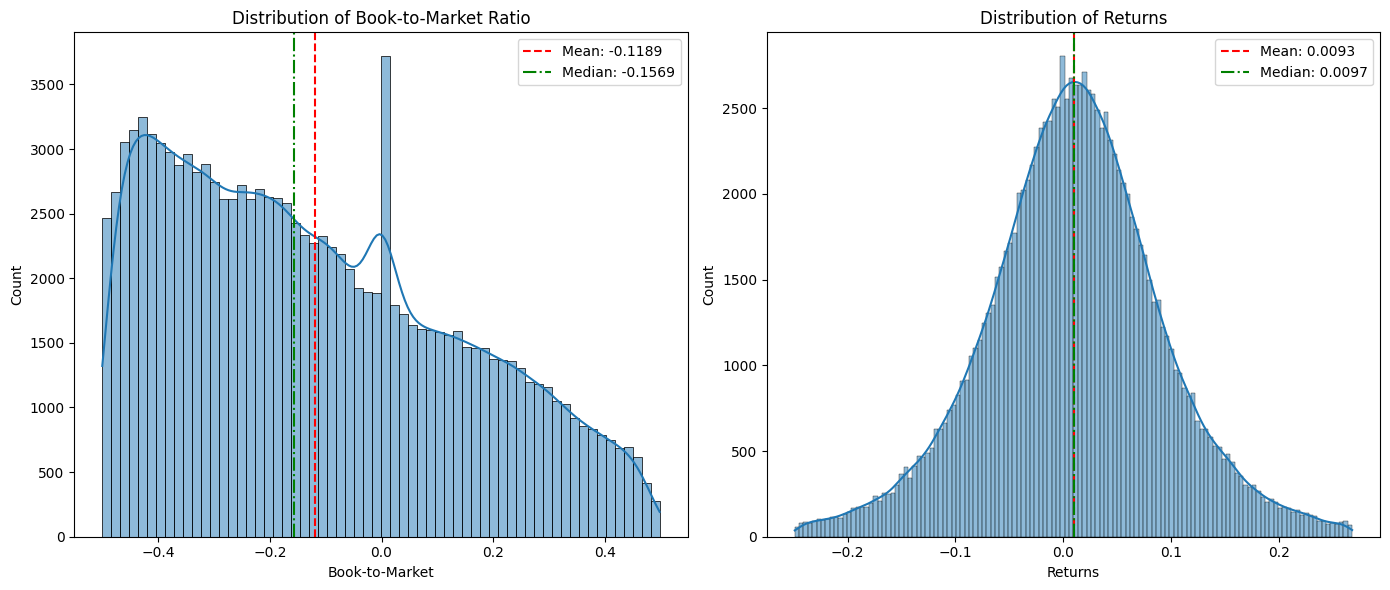

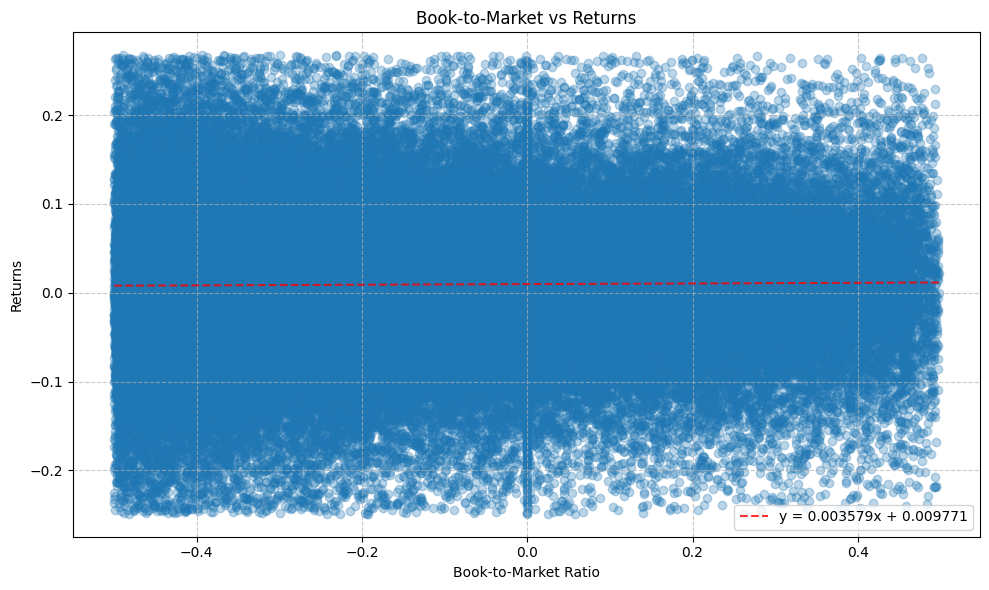

Correlation between Book-to-Market and Returns: 0.0111


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

plt.figure(figsize=(14, 6))

# Book-to-Market distribution
plt.subplot(1, 2, 1)
sns.histplot(df[btm_col], kde=True)
plt.title('Distribution of Book-to-Market Ratio')
plt.xlabel('Book-to-Market')
plt.axvline(df[btm_col].mean(), color='r', linestyle='--', label=f'Mean: {df[btm_col].mean():.4f}')
plt.axvline(df[btm_col].median(), color='g', linestyle='-.', label=f'Median: {df[btm_col].median():.4f}')
plt.legend()

# Returns distribution
plt.subplot(1, 2, 2)
sns.histplot(df[returns_col], kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.axvline(df[returns_col].mean(), color='r', linestyle='--', label=f'Mean: {df[returns_col].mean():.4f}')
plt.axvline(df[returns_col].median(), color='g', linestyle='-.', label=f'Median: {df[returns_col].median():.4f}')
plt.legend()

plt.tight_layout()
plt.show()


# Scatter plot with sklearn LinearRegression
plt.figure(figsize=(10, 6))
plt.scatter(df[btm_col], df[returns_col], alpha=0.3)
plt.title('Book-to-Market vs Returns')
plt.xlabel('Book-to-Market Ratio')
plt.ylabel('Returns')
plt.grid(True, linestyle='--', alpha=0.7)

# Fit linear regression with sklearn
X = df[[btm_col]].values  
y = df[returns_col].values
model = LinearRegression()
model.fit(X, y)

x_vals = np.linspace(df[btm_col].min(), df[btm_col].max(), 500).reshape(-1, 1)
y_pred = model.predict(x_vals)
plt.plot(x_vals, y_pred, "r--", alpha=0.8, 
         label=f'y = {model.coef_[0]:.6f}x + {model.intercept_:.6f}')
plt.legend()

plt.tight_layout()
plt.show()

# Correlation
print(f"Correlation between Book-to-Market and Returns: {df[btm_col].corr(df[returns_col]):.4f}")


Train Regression using sklearn

Manual Linear Regression using Formulas

In [56]:
# Formula: β = (X'X)^(-1)X'y (Linear Regression Coefficients)

X_manual = np.column_stack((np.ones(X_train.shape[0]), X_train))  # Add constant
y_manual = y_train

# Calculate β using the OLS formula
X_transpose_X = X_manual.T @ X_manual
X_transpose_y = X_manual.T @ y_manual
beta = np.linalg.inv(X_transpose_X) @ X_transpose_y

y_pred_manual = X_manual @ beta

y_mean = np.mean(y_manual)
ss_total = np.sum((y_manual - y_mean) ** 2)
ss_residual = np.sum((y_manual - y_pred_manual) ** 2)
r_squared_manual = 1 - (ss_residual / ss_total)

n = len(y_manual)
k = X_manual.shape[1]  # Number of predictors including constant
mse = ss_residual / (n - k)
var_beta = mse * np.linalg.inv(X_transpose_X)
se_beta = np.sqrt(np.diag(var_beta))

t_stats = beta / se_beta
p_values = [2 * (1 - stats.t.cdf(abs(t), n - k)) for t in t_stats]

print("\nManual OLS Results:")
print(f"Coefficients: Intercept = {beta[0]:.6f}, Slope = {beta[1]:.6f}")
print(f"Standard Errors: Intercept = {se_beta[0]:.6f}, Slope = {se_beta[1]:.6f}")
print(f"t-statistics: Intercept = {t_stats[0]:.4f}, Slope = {t_stats[1]:.4f}")
print(f"p-values: Intercept = {p_values[0]:.6f}, Slope = {p_values[1]:.6f}")
print(f"R-squared: {r_squared_manual:.6f}")


Manual OLS Results:
Coefficients: Intercept = 0.009754, Slope = 0.003718
Standard Errors: Intercept = 0.000313, Slope = 0.001110
t-statistics: Intercept = 31.1910, Slope = 3.3492
p-values: Intercept = 0.000000, Slope = 0.000811
R-squared: 0.000134


Compare with Manual Regression

C:\Users\alexh\AppData\Local\Temp\ipykernel_31484\3275270675.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_train, label='Train', shade=True)
C:\Users\alexh\AppData\Local\Temp\ipykernel_31484\3275270675.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_test, label='Test', shade=True)


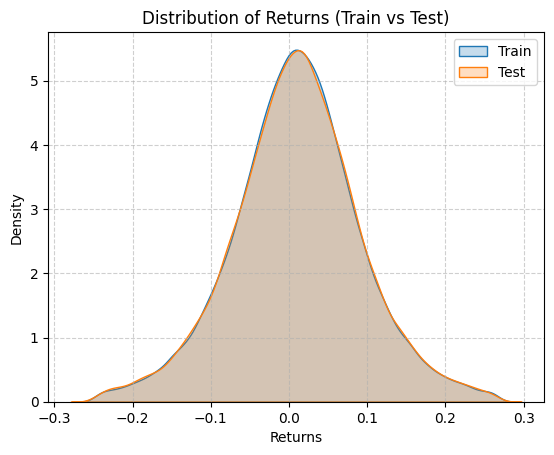

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(y_train, label='Train', shade=True)
sns.kdeplot(y_test, label='Test', shade=True)
plt.title('Distribution of Returns (Train vs Test)')
plt.xlabel('Returns')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



Comparison with sklearn:
Coefficient difference: 0.0001389606
Intercept difference: 0.0000167626
R-squared difference: 0.0000000000


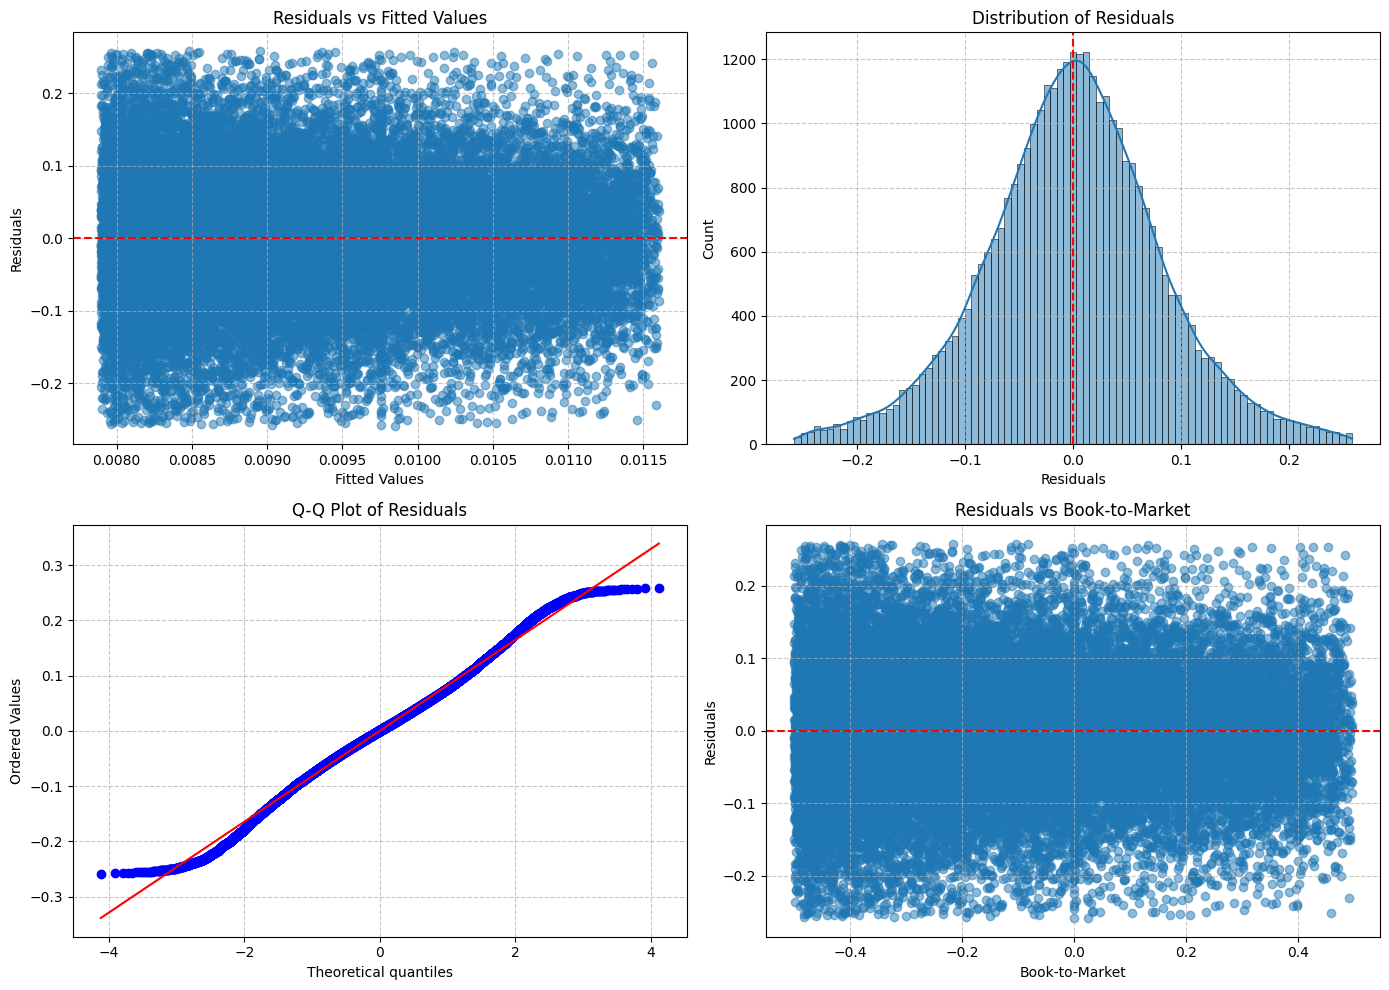


Breusch-Pagan test for heteroscedasticity:
LM statistic: 182.8569
p-value: 0.000000
Heteroscedasticity present (reject H0)


In [62]:

# Compare with sklearn results
print("\nComparison with sklearn:")
print(f"Coefficient difference: {abs(model.coef_[0] - beta[1]):.10f}")
print(f"Intercept difference: {abs(model.intercept_ - beta[0]):.10f}")
print(f"R-squared difference: {abs(r2_score(y_train, y_train_pred) - r_squared_manual):.10f}")

residuals = y_test - y_test_pred

plt.figure(figsize=(14, 10))

# Residuals vs Fitted values
plt.subplot(2, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
plt.subplot(2, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)

# Q-Q plot of residuals
plt.subplot(2, 2, 3)
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Residuals vs Book-to-Market
plt.subplot(2, 2, 4)
plt.scatter(X_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Book-to-Market')
plt.xlabel('Book-to-Market')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Test for whether variance of the residuals changes with the input variables
# Breusch-Pagan test
X_test_sm = sm.add_constant(X_test)
model_test = sm.OLS(y_test, X_test_sm).fit()
bp_test = sm.stats.diagnostic.het_breuschpagan(model_test.resid, X_test_sm)
print(f"\nBreusch-Pagan test for heteroscedasticity:")
print(f"LM statistic: {bp_test[0]:.4f}")
print(f"p-value: {bp_test[1]:.6f}")
if bp_test[1] < 0.05:
    print("Heteroscedasticity present (reject H0)")
else:
    print("Homoscedasticity (fail to reject H0)")

Test, Plots, and data Analysis

We see the residual analysis suggests that the linear regression model is reasonably well-behaved. Residuals are centered around zero with constant variance, indicating no major issues with heteroscedasticity or non-linearity. The distribution of residuals appears roughly normal, though the Q-Q plot shows slight deviations in the tails, suggesting minor non-normality. Overall, the model assumptions are largely satisfied, supporting the validity of the regression results.